# Tidal response method — minimal demo

This notebook shows the whole workflow on **synthetic data**: give the model a
sea-level time series and a list of tidal constituents, and it returns their
**amplitudes and phases**.

The method (Munk & Cartwright *response* analysis) regresses the observations
onto the astronomical tide-generating forcing at a set of time lags. The fitted
lag weights define a smooth complex *admittance* `H(f)`; the amplitude and phase
of any constituent are read off by applying `H` to that constituent's forcing
line. Unlike classical harmonic analysis it borrows strength across each tidal
band, so a handful of parameters pin down the whole band.

**Four-step API**

```python
model = TidalResponseLS(lat, lon)                      # 1. pick a station
model.fit(ts, uniform_lags=(n, dt_hours), ...)         # 2. fit the admittance
fdf  = model.forcing_at(ts.index)                      # 3. astronomical forcing
_, hc = model.harmonic_from_admittance(                # 4. read off amp/phase
            ts.index, fdf, constituents=[...])
```

`ts` is a `DataFrame` with a `DatetimeIndex` and one column named
`observations`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from response_method import TidalResponseLS

# Cache the (expensive) astronomical forcing so re-fits at this station are fast.
FORCING_CACHE = ".forcing_cache"
STATION = dict(lat=41.0, lon=-71.0)   # a point off the US northeast shelf

## 1. Make a synthetic sea-level record

We build hourly "observations" as a sum of tidal constituents, each
`A cos(2 pi f t + phase)`, using standard constituent frequencies (cycles/day)
and realistic-ish amplitudes, then add a little measurement noise. These chosen
values are the **ground truth** we will try to recover.

35,064 hourly samples over 2013-01-01 .. 2016-12-31


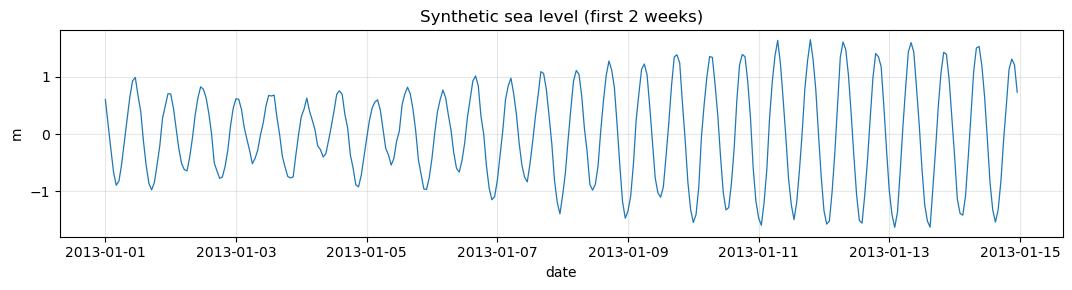

In [2]:
# constituent frequencies (cycles per day)
FREQS = {"M2": 1.932274, "S2": 2.000000, "N2": 1.895982,
         "K1": 1.002738, "O1": 0.929536}

# ground-truth amplitude (m) and phase (deg) we will inject
TRUTH = {"M2": (1.20,  40.0),
         "S2": (0.40, 150.0),
         "N2": (0.23, -70.0),
         "K1": (0.15, 200.0),
         "O1": (0.10, -30.0)}

idx = pd.date_range("2013-01-01", "2016-12-31 23:00", freq="1h")
t0  = idx[0]
t_days = (idx - t0).total_seconds().to_numpy() / 86400.0

sea_level = np.zeros(len(idx))
for name, (amp, phase) in TRUTH.items():
    sea_level += amp * np.cos(2 * np.pi * FREQS[name] * t_days + np.deg2rad(phase))
sea_level += 0.05 * np.random.default_rng(0).standard_normal(len(idx))  # 5 cm noise

ts = pd.DataFrame({"observations": sea_level}, index=idx)

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(ts.index[:24*14], ts["observations"].iloc[:24*14], lw=0.9)
ax.set(title="Synthetic sea level (first 2 weeks)", ylabel="m", xlabel="date")
ax.grid(alpha=0.3)
fig.tight_layout()
print(f"{len(ts):,} hourly samples over {ts.index[0].date()} .. {ts.index[-1].date()}")

## 2. Fit the response model

`uniform_lags=(n, dt_hours)` places forcing lags at `0, +/-dt, ..., +/-n*dt`
hours (`symmetrical=True` adds the negative side). More lags give the admittance
more freedom across each band. `estimator="vbayes"` uses the built-in
variational-Bayes solver (automatic shrinkage + uncertainty); `"ols"` is plain
least squares.

The first fit at a new station computes the astronomical forcing via the
`skyfield` ephemeris (downloads `de421.bsp` once, ~17 MB) and caches it.

In [3]:
model = TidalResponseLS(**STATION,
                        forcing_use_cache=True,
                        forcing_cache_dir=FORCING_CACHE)

model.fit(ts,
          uniform_lags=(3, 12),     # lags at 0, +/-12, +/-24, +/-36 h
          symmetrical=True,
          estimator="ols",
          base_freq="30min",        # forcing grid resolution
          forcing_use_cache=True)

print("fit R^2 =", round(model.resid_stats_["r2"][0], 5))

fit R^2 = 0.98389


## 3. Read off amplitudes and phases

Ask for whatever constituents you like — they can span diurnal and semidiurnal
bands. `harmonic_from_admittance` returns a table with `amp_observations` and
`phase_observations_deg` per constituent.

In [4]:
fdf = model.forcing_at(ts.index, forcing_use_cache=True)

_, hc = model.harmonic_from_admittance(
            ts.index, fdf,
            constituents=list(TRUTH),   # the constituents we want
            t0=t0)

# tidy comparison against the injected truth
rows = []
for _, r in hc.iterrows():
    n = r["constituent"]
    amp_t, ph_t = TRUTH[n]
    # wrap phase error into (-180, 180]
    dph = (r["phase_observations_deg"] - ph_t + 180) % 360 - 180
    rows.append(dict(constituent=n,
                     amp=round(r["amp_observations"], 4), amp_true=amp_t,
                     phase=round(r["phase_observations_deg"], 1), phase_true=ph_t,
                     amp_err=round(r["amp_observations"] - amp_t, 4),
                     phase_err=round(dph, 1)))
pd.DataFrame(rows).set_index("constituent")

/opt/anaconda3/lib/python3.11/site-packages/utide/harmonics.py:16: RuntimeWarning: invalid value encountered in cast
  nshallow = np.ma.masked_invalid(const.nshallow).astype(int)
/opt/anaconda3/lib/python3.11/site-packages/utide/harmonics.py:17: RuntimeWarning: invalid value encountered in cast
  ishallow = np.ma.masked_invalid(const.ishallow).astype(int) - 1


,amp,amp_true,phase,phase_true,amp_err,phase_err
constituent,,,,,,
M2,1.1924,1.20,40.0,40.0,-0.0076,0.0
S2,0.3913,0.40,149.0,150.0,-0.0087,-1.0
N2,0.1925,0.23,-72.1,-70.0,-0.0375,-2.1
K1,0.1398,0.15,-160.4,200.0,-0.0102,-0.4
O1,0.0969,0.10,-30.5,-30.0,-0.0031,-0.5


The dominant lines (M2, S2, K1, O1) recover to ~1–3 % in amplitude and a few
degrees in phase. N2 typically shows a larger amplitude error: the response
method assumes a **smooth admittance across each band**, so it ties the minor
N2 line to the dominant M2 rather than fitting it independently. That shared
smoothness is exactly what lets the method work from short or gappy records —
but it means constituents that depart from the natural band shape are the least
well constrained. Adding more lags relaxes this at the cost of variance.

You can also just look at the fitted admittance across a band:

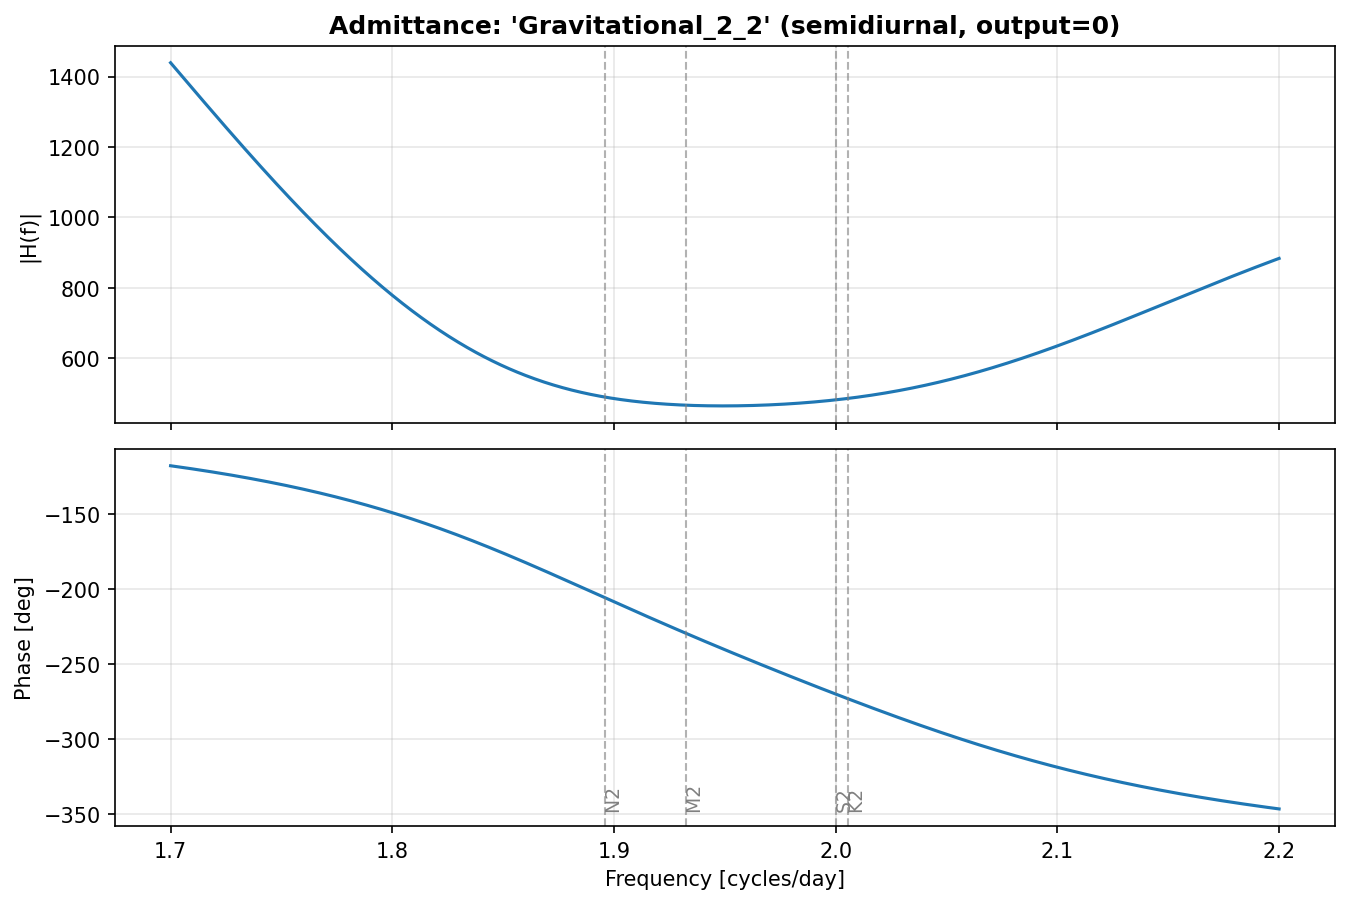

In [5]:
fig = model.plot_admittance_band("Gravitational_2_2", band="semidiurnal")
fig.set_size_inches(9, 6)

## Bonus: a linear amplitude *trend*

Passing `trend=True` lets the admittance drift **linearly in time**, so each
constituent gets an amplitude *rate* (per year) alongside its mean amplitude.

One subtlety is worth understanding first. The response method models sea level
as the ocean's *response to the astronomical forcing*, and that forcing is
essentially stationary over a few years. So the trend term captures a change in
**how strongly the ocean responds** — not an arbitrary drift bolted onto the
series. (Growing a bare sinusoid would *not* show up as a trend here, because
nothing in the forcing grew.) To demonstrate the feature we therefore build a
forcing-derived tide and let its response strengthen at a known rate `g` — a
slowly amplifying tide — then recover `g`.

We reuse the same station and cached forcing, so this is fast.

In [6]:
years = t_days / 365.2425

# A forcing-derived "true tide": real gains on gravitational forcing lines give a
# realistic, M2-dominated multi-constituent signal that the model can represent.
gains = {"Gravitational_2_2": 9.0, "Gravitational_2_1": 4.0}
tide = sum(g * np.real(fdf[c].to_numpy()) for c, g in gains.items())
tide = tide / tide.std() * 0.45                      # ~0.45 m RMS

G = 0.010                                            # tide strengthens 1 %/yr
sea_level_tr = (1 + G * years) * tide
sea_level_tr += 0.03 * np.random.default_rng(2).standard_normal(len(idx))
ts_tr = pd.DataFrame({"observations": sea_level_tr}, index=idx)

model_tr = TidalResponseLS(**STATION, forcing_use_cache=True, forcing_cache_dir=FORCING_CACHE)
model_tr.fit(ts_tr, uniform_lags=(2, 24), symmetrical=True, estimator="ols",
             base_freq="30min", trend=True, forcing_use_cache=True)

_, hc_tr = model_tr.harmonic_from_admittance(ts_tr.index, fdf, constituents=list(TRUTH), t0=t0)

out = hc_tr[["constituent", "amp_observations", "amp_rate_observations_per_year"]].copy()
out["frac_rate_per_yr"] = out["amp_rate_observations_per_year"] / out["amp_observations"]
out.columns = ["constituent", "amp_mean_m", "amp_rate_m_per_yr", "frac_rate_per_yr"]
out = out.set_index("constituent").round(5)
print("injected fractional growth g = +{:.4f} /yr (same for every line)\n".format(G))
out

injected fractional growth g = +0.0100 /yr (same for every line)



,amp_mean_m,amp_rate_m_per_yr,frac_rate_per_yr
constituent,,,
M2,0.53837,0.00504,0.00937
S2,0.24554,0.00228,0.00930
N2,0.14666,0.00075,0.00514
K1,0.16125,0.00148,0.00918
O1,0.10638,0.00124,0.01170


Every constituent's `frac_rate_per_yr = amp_rate / amp` recovers the injected
`g ~ +0.010 /yr` (N2, the weakly-constrained satellite line, is the softest —
same reason as above). The mean amplitude is reported at the record midpoint,
the trend's reference epoch.

The identical mechanism generalises from *time* to **physical covariates** — the
admittance can be made to vary with sea level, stratification, etc. instead of
with `t` — via `admittance(..., covariate=...)` and `fit(..., covariates=...)`
in `response_method.py`. That is beyond this minimal demo.